# Graph Data Science (GDS) Analysis

This notebook applies Neo4j Graph Data Science algorithms to the **CIC-UNSW-NB15** dataset. We focus on the `:Host` nodes and their aggregated `:CONNECTED_TO` relationships to identify structural risks, communication communities, and behavioral anomalies.

### Key Objectives:
1. **Centrality:** Identify bottleneck hosts and high-influence nodes.
2. **Community Detection:** Discover natural groupings of hosts to detect potential botnets.
3. **Similarity:** Find hosts that behave similarly to known attackers.
4. **Embeddings:** Generate low-dimensional representations for downstream ML.

The goal here is simply exemplifying the use of GDS algorithms on the network-flow graph, introducing the reader to the concepts and tools. The next notebook, [`ml-gds.ipynb`](ml-gds.ipynb), will show how to combine GDS with machine learning for anomaly detection.

## Setup

Connect to Neo4j and verify that the GDS plugin is available.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from neo4j_analysis import Neo4jAnalysis

load_dotenv()
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110

analysis = Neo4jAnalysis(
    os.getenv("NEO4J_URI"),
    os.getenv("NEO4J_USERNAME"),
    os.getenv("NEO4J_PASSWORD"),
    os.getenv("NEO4J_DATABASE"),
)

RENDER_DIR = os.getenv("RENDER_DIR", "renderings")
os.makedirs(RENDER_DIR, exist_ok=True)

# Verify GDS availability
try:
    gds_version = analysis.run_query_single("RETURN gds.version() as version")[
        "version"
    ]
    print(f"GDS Version: {gds_version}")
except Exception as e:
    print(
        "GDS plugin not found. Please ensure Graph Data Science is installed on your Neo4j instance."
    )
    print(e)

GDS plugin not found. Please ensure Graph Data Science is installed on your Neo4j instance.
{neo4j_code: Neo.DatabaseError.Statement.ExecutionFailed} {message: Aura Graph Analytics is versionless.} {gql_status: 50N00} {gql_status_description: error: general processing exception - internal error. Internal exception raised CypherExecution: Aura Graph Analytics is versionless.}


## Graph Projection

Before running algorithms, we must project the relevant portion of the graph into the GDS in-memory catalog. We project `:Host` nodes and the aggregated `:CONNECTED_TO` relationships, including properties for flow counts and bytes.

In [2]:
# Drop existing projection if it exists
analysis.run_query("""
    CALL gds.graph.list() YIELD graphName
    WHERE graphName = 'host-network'
    CALL gds.graph.drop(graphName) YIELD graphName AS dropped
    RETURN dropped
""")

# Create new projection using Aura Graph Analytics syntax
projection_res = analysis.run_query_single("""
    CALL gds.graph.project(
      'host-network',
      'Host',
      'CONNECTED_TO',
      {
        relationshipProperties: ['flows', 'attackFlows', 'bytes'],
        memory: '2GB'
      }
    )
    YIELD graphName, nodeCount, relationshipCount
    RETURN graphName, nodeCount, relationshipCount
""")

print(
    f"Projected graph '{projection_res['graphName']}' with {projection_res['nodeCount']} nodes and {projection_res['relationshipCount']} relationships."
)

Projected graph 'host-network' with 43 nodes and 293 relationships.


## Centrality Analysis

### PageRank
PageRank measures the "influence" of a host. In a network-flow context, high PageRank often identifies critical servers or central gateways.

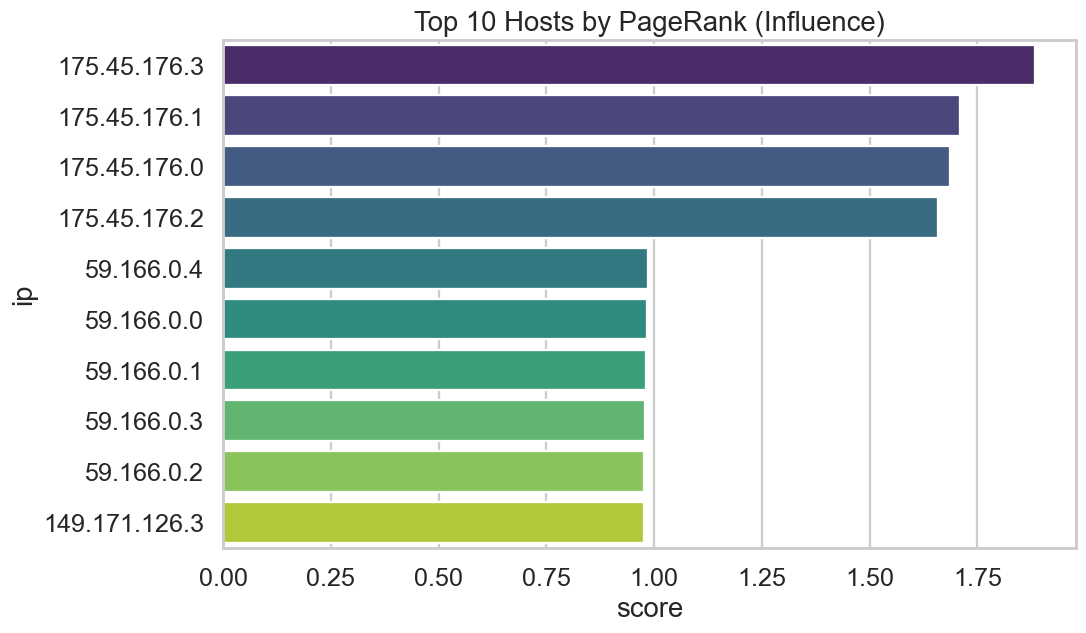

In [3]:
pagerank_df = analysis.run_query_df("""
    CALL gds.pageRank.stream('host-network', {
      relationshipWeightProperty: 'flows'
    })
    YIELD nodeId, score
    RETURN gds.util.asNode(nodeId).ip AS ip, score
    ORDER BY score DESC LIMIT 10
""")

plt.figure(figsize=(10, 6))
sns.barplot(data=pagerank_df, x="score", y="ip", hue="ip", palette="viridis")
plt.title("Top 10 Hosts by PageRank (Influence)")
plt.show()

### Betweenness Centrality
Betweenness identifies hosts that act as bridges. These are critical "bottlenecks" where lateral movement might be detected.

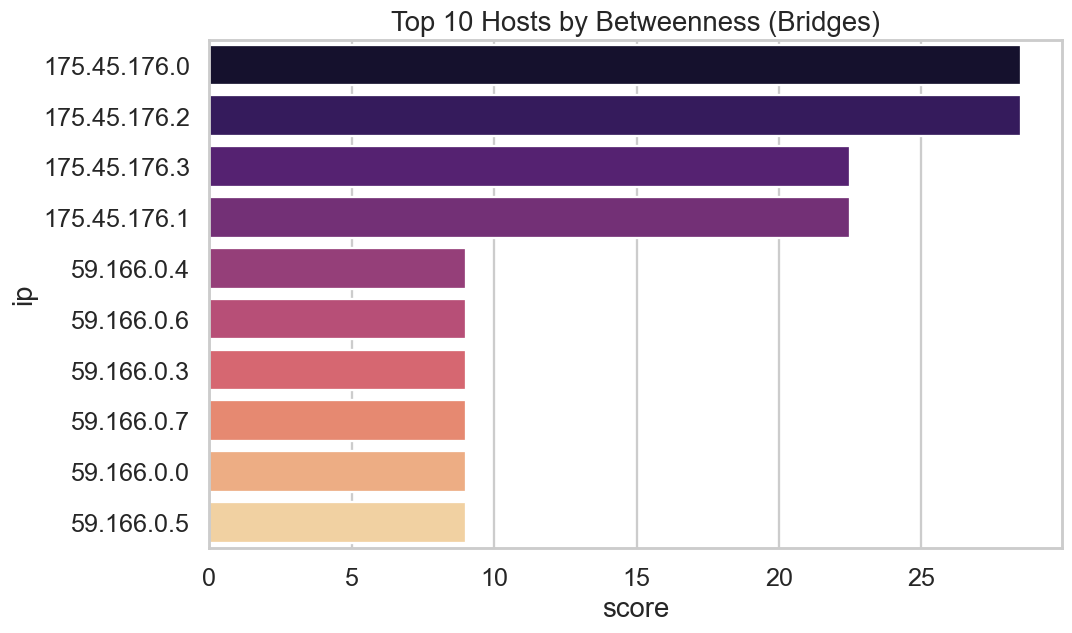

In [4]:
betweenness_df = analysis.run_query_df("""
    CALL gds.betweenness.stream('host-network')
    YIELD nodeId, score
    RETURN gds.util.asNode(nodeId).ip AS ip, score
    ORDER BY score DESC LIMIT 10
""")

plt.figure(figsize=(10, 6))
sns.barplot(data=betweenness_df, x="score", y="ip", hue="ip", palette="magma")
plt.title("Top 10 Hosts by Betweenness (Bridges)")
plt.show()

## Community Detection (Louvain)

Louvain discovers natural clusters based on communication density. We can use this to see if attackers and victims are tightly clustered. The plot below shows the communities detected, with colors representing different clusters. Larger communities indicates hosts that communicate more frequently with each other, which may suggest coordinated activity (whether benign or not).

Clusters are grouped by their subnet (using the `:Subnet` nodes).

Found 6 communities.


,communityId,host_count
0,14,20
1,15,15
2,34,1
3,36,1
4,38,4
5,40,2


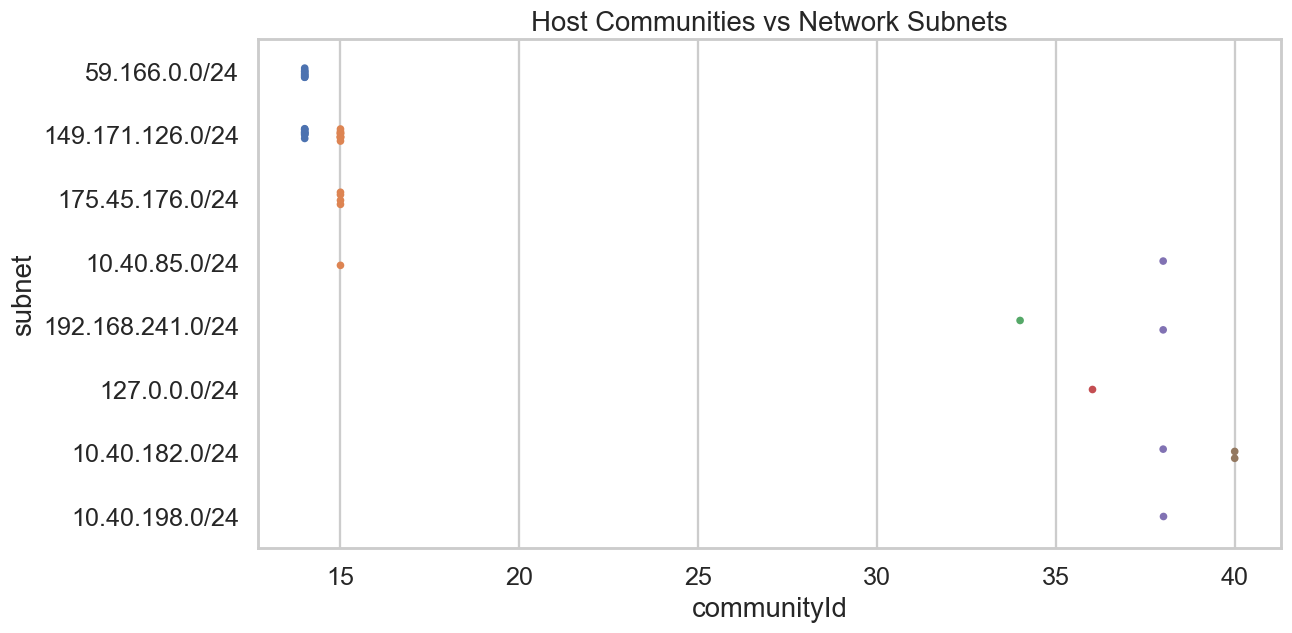

In [5]:
louvain_df = analysis.run_query_df("""
    CALL gds.louvain.stream('host-network')
    YIELD nodeId, communityId
    MATCH (h:Host {ip: gds.util.asNode(nodeId).ip})
    MATCH (h)-[:IN_SUBNET]->(s:Subnet)
    RETURN h.ip AS ip, s.cidr AS subnet, communityId
    ORDER BY communityId
""")

print(f"Found {louvain_df['communityId'].nunique()} communities.")
display(louvain_df.groupby("communityId")["ip"].count().reset_index(name="host_count"))

# Visualizing communities vs subnets
plt.figure(figsize=(12, 6))
sns.stripplot(
    data=louvain_df,
    x="communityId",
    y="subnet",
    hue="communityId",
    palette="deep",
    legend=False,
)
plt.title("Host Communities vs Network Subnets")
plt.show()

## Behavioral Similarity & Embeddings

### FastRP Embeddings
FastRP generates vectors representing each host's position and relationship context in the graph. These can be used to find hosts that "look" like attackers for example, or to identify clusters of similar behavior. This is very useful for anomaly detection, as hosts that are structurally similar to known attackers may warrant further investigation.

In [6]:
# Generate embeddings
analysis.run_query("""
    CALL gds.fastRP.mutate('host-network', {
      embeddingDimension: 16,
      mutateProperty: 'embedding'
    })
    YIELD nodePropertiesWritten
""")

# Find top 5 similar hosts to a known attacker (e.g., 175.45.176.0)
similarity_df = analysis.run_query_df("""
    MATCH (h:Host {ip: '175.45.176.0'})
    CALL gds.knn.stream('host-network', {
      nodeProperties: ['embedding'],
      topK: 6,
      sampleRate: 1.0
    })
    YIELD node1, node2, similarity
    WITH h, node1, node2, similarity  // Now 'h' is successfully carried over here
    WHERE gds.util.asNode(node1) = h
    RETURN gds.util.asNode(node2).ip AS similar_ip, similarity
    ORDER BY similarity DESC
""")

print("Hosts most behaviorally similar to attacker 175.45.176.0:")
display(similarity_df)

Hosts most behaviorally similar to attacker 175.45.176.0:


,similar_ip,similarity
0,175.45.176.2,1.000000
1,175.45.176.3,1.000000
2,175.45.176.1,1.000000
3,149.171.126.19,0.999134
4,149.171.126.14,0.998750
5,149.171.126.13,0.998750


Now let us visualize the original IP, and the most similar IP to it, together with its neighbors.

In [7]:
from neo4j_viz.neo4j import from_neo4j


async def render_and_capture(VG, name, width=1600, height=1000, scale=2):
    """Render a VisualizationGraph to renderings/<name>.png via the Playwright helper."""
    html = VG.render(width=f"{width}px", height=f"{height}px")
    html_path = os.path.join(RENDER_DIR, f"{name}.html")
    with open(html_path, "w", encoding="utf-8") as f:
        f.write(html.data)
    png_path = os.path.join(RENDER_DIR, f"{name}.png")
    # Passing html_file= reuses the saved layout and skips the centering-CSS injection,
    # which otherwise resizes the NVL canvas and clips the graph.
    await analysis.capture_graph_to_png(
        None, png_path, width=width, height=height, scale=scale, html_file=html_path
    )
    print("saved", png_path)
    return png_path

saved renderings/similar_hosts.png


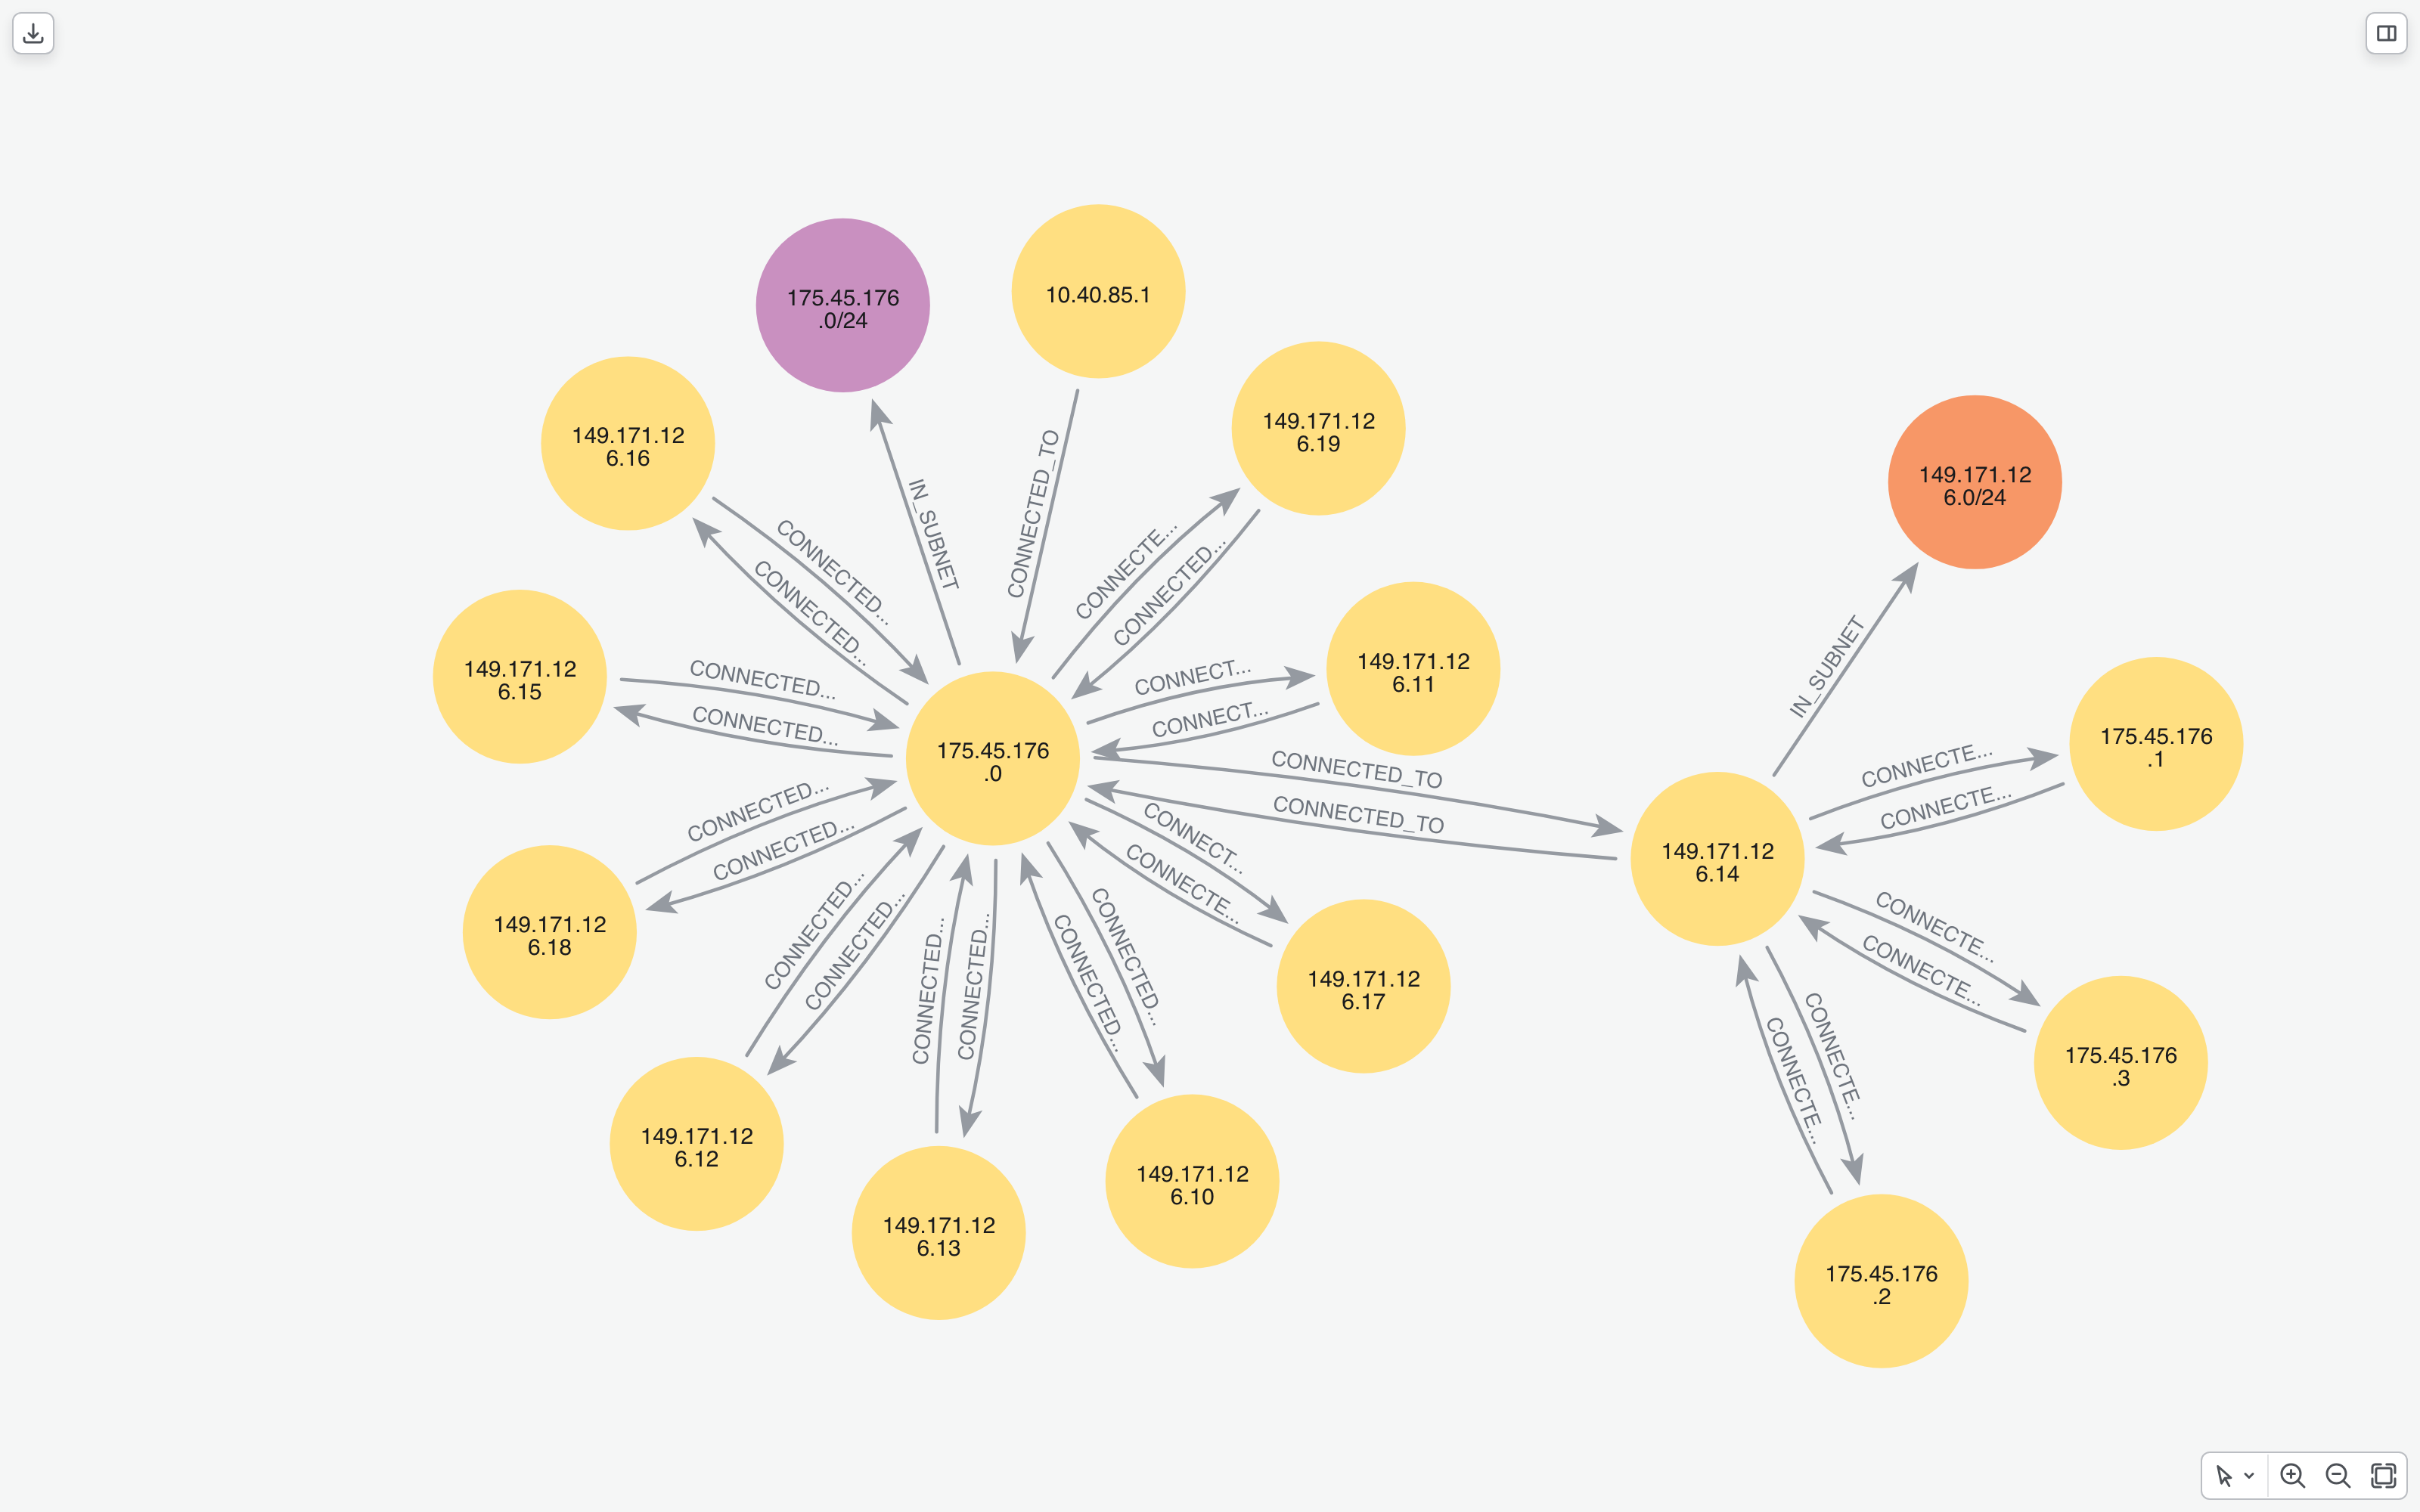

In [8]:
from IPython.display import Image, display

# 1. Extract the top scored similar IP from your DataFrame
target_ip = "175.45.176.0"
top_similar_ip = similarity_df.iloc[4]["similar_ip"]

# 2. Run the visualization query returning full paths
g = analysis.run_query_viz(
    """
    MATCH path = (n:Host)-[:CONNECTED_TO|IN_SUBNET]-()
    WHERE n.ip IN [$target, $similar]
    RETURN path
""",
    params={"target": target_ip, "similar": top_similar_ip},
)

VG = from_neo4j(g)
VG.color_nodes(property="cidr")

png = await render_and_capture(VG, "similar_hosts")
display(Image(filename=png))

## Cleanup

Drop the in-memory graph projection and close the connection.

In [9]:
analysis.run_query("CALL gds.graph.drop('host-network') YIELD graphName")
analysis.close()
print("Projection dropped and connection closed.")

Projection dropped and connection closed.
